# GMT 454 HW 3,4

## Trend Surface Analysis

In this homework, you are given a sampled dataset from a field of Land Surface Temperature in Celcius degrees near Ankara/Turkey. land Surface Temperature values are extracted from Google Earth Engine.

### HW3 

#### Part 1 (60 pts): 
You are asked in the scope of HW3 to fit a second degree polynomial surface to the given dataset and create a raster representation of the region given the bounds of easting and northing in TUREF TM33 (min easting: 485435.759343379, min northing: 4347566.170745882) (max easting: 649482.195943379, max northing: 4433737.105945882). The resulting raster shall have dimension of width:100 and height:40.

#### Part 2 (40 pts):

Discuss whether second degree polynomial is a good choice or not for the given task. Which kind of tests are required to provide a better judgement on the quality. Can we get better results by aplying least squares with other basis fuctions?


### HW4

#### Part 1 (60 pts): 

You are asked in the scope of HW4 to apply ordinary kiriging to the given dataset and create a raster representation of the region given the bounds of easting and northing in TUREF TM33 (min easting: 485435.759343379, min northing: 4347566.170745882) (max easting: 649482.195943379, max northing: 4433737.105945882). The resulting raster shall have a dimension of width:100 and height:40.

#### Part 2(40 pts):

Discuss advantages and disadvantages of Kriging over Least squares in HW3. In which cases least squares may provide better results than ordinary kriging?

The original surface as a reference for your discussion parts:

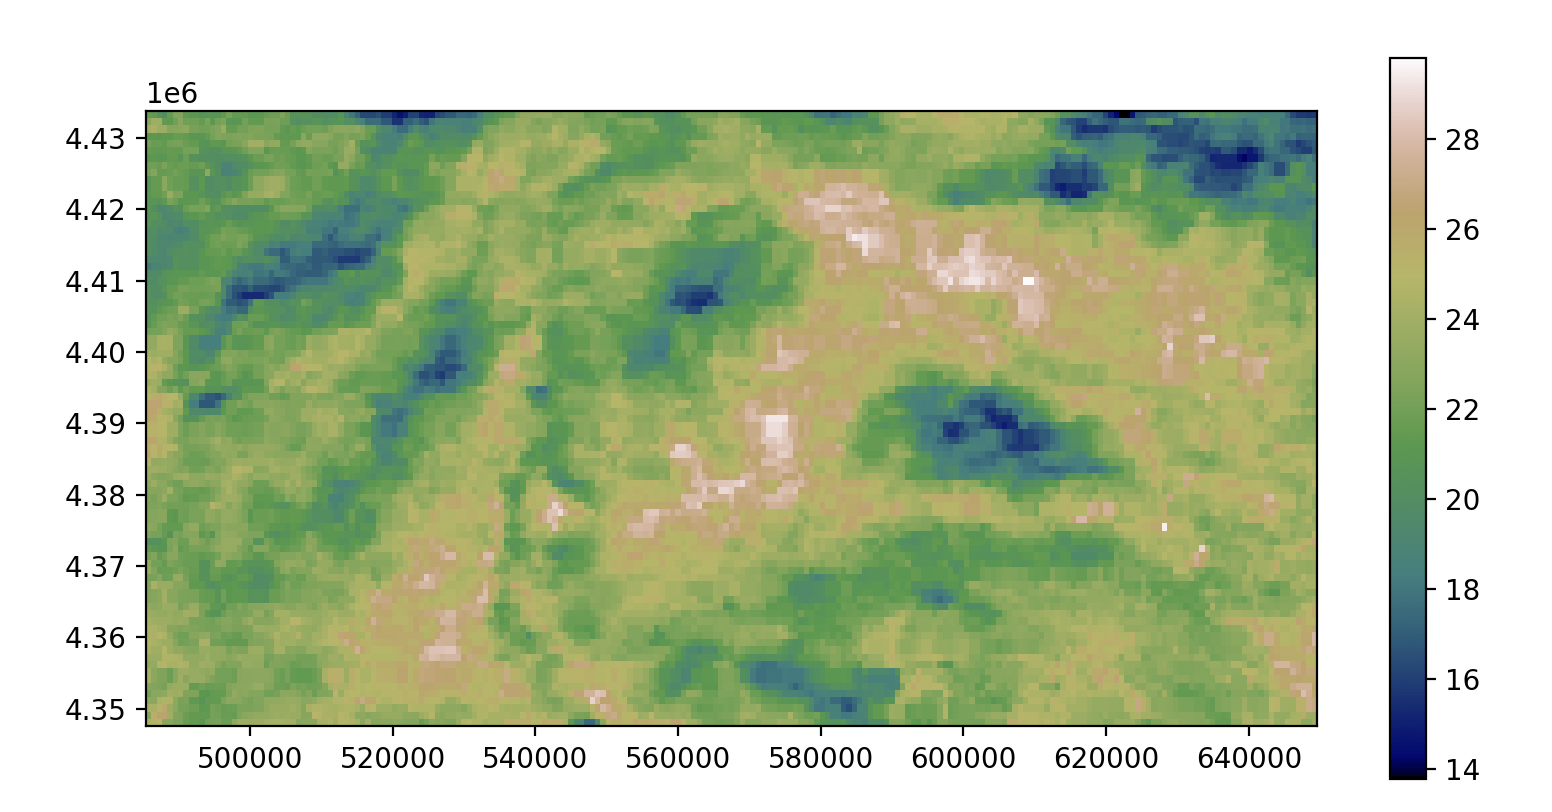

## Due Date

Due date 04/06/2026 not later than midnight.

## Submission
Submit your jupyter notebook to course page at http://hadi.hacettepe.edu.tr. **Rename your files to include your name and surname.**


## Prerequsites

1. If you did not installed already, please install Anaconda python distribution.
2. This homework requires the following modules may be requires
    - scikit-gstat

### Initialize the environment

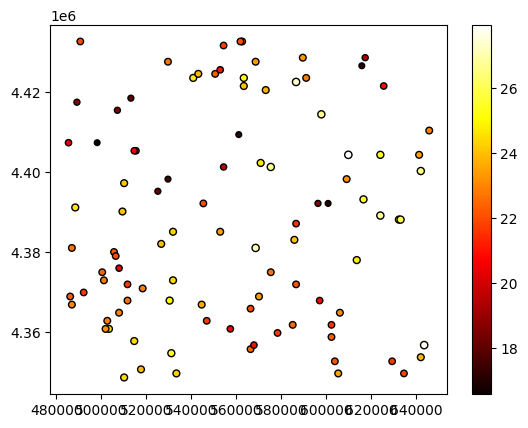

In [1]:
###### IMPORTANT NOTICE #######
# you have to correct the code by substituting the correct phrase 
# with the parts given as question mark: '?' 
############


import numpy as np
import matplotlib.pyplot as plt

def load_data():
    data = np.load('hw3_4_data.npz')
    return data['x'],data['y'],data['z'],data['bounds']


# e: Eastings, n: Northings, t: Land surface Temperature, 
# bounds: [min_easting, min_northing, max_easting, max_northing]
e,n,t,bounds = load_data()

plt.scatter(e, n, s=t, c=t, cmap='hot',edgecolor='black')
plt.colorbar()

###
# Create a raster of nx by ny dimensions
# returns: 
# eastings: the easting coordinates of each grid location
# northings: the northing coordinates of each grid location
# Z: the grid to hold land surface temperature values

def create_resulting_raster(nx, ny, bounds):
    # There will be nx eastings in the resulting raster 
    # ranging from min easting to max easting
    eastings = np.linspace(bounds[0],bounds[2],nx)
    
    # The same for northings
    northings = np.linspace(bounds[1],bounds[3],ny)
    
    XX, YY = np.meshgrid(eastings, northings)
    
    return XX, YY, np.zeros_like(XX)


# HW3 PART 1: Least Squares

Fill in the missing parts of the following code segment to create a model of temperature $t(x,y)$ as a second degree polynomial over the region.

$$
t(x,y) = \beta_0 + \beta_1 x^1 + \beta_2 y^1 + \beta_3 x^1 y^1 + \beta_4 x^2 + \beta_5 y^2
$$

The measurements are loaded as variable $t$ in the previous cell.
The correspoding x and y are easting and northing values loaded from the dataset

Note !!! we do not use easting and northing directly to cope with numerical issues of representing large numbers. thus we normalize easting and northing to obtain values of x and y as:

$$
x = \frac{(e - easting_{min})} { (easting_{max} - easting_{min})}
$$

and

$$
y = \frac{(n - northing_{min})} { (northing_{max} - northing_{min})}
$$

Form the least squares observation eqation

$$
t = X\beta
$$

and solve by numpy lstsq method.

In [ ]:


x = (e - ?) / (bounds[2] - bounds[0])
y = (n - bounds[1]) / (bounds[3] - ? )



X = np.vstack(
    (
        np.ones_like(t),
        ?,
        ?,
        ?,
        ?,
        ?
    )
).T

betas = np.linalg.lstsq(X,t,rcond=None)[0]

residuals = t - np.dot(X,betas)

var = np.sum(residuals**2)/(len(t)-5)

var_beta = var*np.linalg.inv(np.dot(X.T,X))

print ('measurement variance ', var, 'Estimated parameters ', betas, ' And associated uncertainity ', np.sqrt(np.diag(var_beta)))


Now we have the estimated parameter create the resulting raster by using the estimated parameters in the array $betas$

In [ ]:

XX, YY, Z = create_resulting_raster(100, 40, bounds)

# For each row in 
for row in range(Z.shape[0]):
    for col in range(Z.shape[1]):
        
        # Not that these are the normal grid coordinates
        # we need to scale them to modeling coordinates in least squares estimation
        
        cur_x = (XX[row,col] - bounds[0])/(? - bounds[0])
        cur_y = (YY[row,col] - bounds[1])/(bounds[3] - ?)
        
        Z[row, col] = betas[?] + \
                      betas[?]*cur_x + \
                        betas[?]*cur_y + \
                        betas[?]*cur_x**2 +\
                        betas[?]*cur_y**2

        
#Now plot the resulting raster and residuals

plt.imshow(Z,extent=(bounds[0],bounds[2],bounds[1],bounds[3]),origin='lower',cmap='gist_earth')
plt.scatter(e, n, s=residuals*10, c=residuals, cmap='hot',edgecolor='black')
plt.colorbar()
    

# HW3 Part 2: Discussion

Discuss whether second degree polynomial is a good choice or not for the given task. Which kind of tests are required to provide a better judgement on the quality. Can we get better results by aplying least squares with other basis fuctions?


# HW4 PART 1, Kriging

Now apply ordinary kriging to the dataset and plot both the resulting raster and also the error map

In [ ]:
from skgstat import Variogram, OrdinaryKriging

V1 = Variogram(np.vstack((?, ?)).T, t, normalize=False)
V1.n_lags = 10
V1.plot(show=False);

In [ ]:
XX_krig, YY_krig, Z_krig = create_resulting_raster(?, ?, bounds)

ok = OrdinaryKriging(V1, min_points=?, max_points=?, mode='exact')
field = ok.transform(XX_krig.ravel(), YY_krig.ravel())
    
Z_krig[:]= field.reshape(40,100)

plt.imshow(Z_krig,extent=(bounds[0],bounds[2],bounds[1],bounds[3]),origin='lower',cmap='gist_earth')
plt.scatter(e, n, s=t, c=t, cmap='gist_earth',edgecolor='black')
plt.colorbar()


Now plot the error map of kriging

In [ ]:
E_krig = ?

plt.imshow(E_krig,extent=(bounds[0],bounds[2],bounds[1],bounds[3]),origin='lower',cmap='gist_earth')

plt.colorbar()


# HW4 Part 2: Discussion

Discuss the advantages and disadvantages of Kriging over Least squares. In which cases least squares may provide better results than ordinary kriging?